Rows after fixing: 63982
     cmte_id    cand_id             cand_nm           contbr_nm  \
0  C00410118  P20002978  Bachmann, Michelle     HARVEY, WILLIAM   
1  C00410118  P20002978  Bachmann, Michelle     HARVEY, WILLIAM   
2  C00410118  P20002978  Bachmann, Michelle       SMITH, LANIER   
3  C00410118  P20002978  Bachmann, Michelle    BLEVINS, DARONDA   
4  C00410118  P20002978  Bachmann, Michelle  WARDENBURG, HAROLD   

          contbr_city contbr_st contbr_zip        contbr_employer  \
0              MOBILE        AL  366010290                RETIRED   
1              MOBILE        AL  366010290                RETIRED   
2              LANETT        AL  368633403  INFORMATION REQUESTED   
3             PIGGOTT        AR  724548253                   NONE   
4  HOT SPRINGS NATION        AR  719016467                   NONE   

       contbr_occupation contb_receipt_amt($) contb_receipt_dt receipt_desc  \
0                RETIRED                  250        20-JUN-11                

/tmp/ipykernel_3032/860377244.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['contb_receipt_dt'] = pd.to_datetime(df['contb_receipt_dt'], errors='coerce')


Rows after cleaning: 63982

Top Donors:
 contbr_nm
JOHNSON, WILLIAM B. MR.       11250.00
FRYE, MEGAN MS.               10000.00
NELSON, JOHN P. MR.           10000.00
BRANDT, RICK MR.              10000.00
GREEN, JEFFREY MR.            10000.00
SCHAR, DWIGHT C. MR.          10000.00
SECHRIST, JAMES RONALD MR.     9599.40
LOEFFLER, KELLY L. MS.         7914.31
JOHNSON, JEFF M. MR.           7500.00
JACOBS, JAMES W. MR.           7500.00
Name: contb_receipt_amt($), dtype: float64

Occupation Stats:
                                         count         mean         sum
contbr_occupation                                                     
RETIRED                                 16500   438.150707  7229486.67
INFORMATION REQUESTED PER BEST EFFORTS   7800   865.851237  6753639.65
HOMEMAKER                                3901  1222.661728  4769603.40
ATTORNEY                                 3203   918.676859  2942521.98
PRESIDENT                                1263  1232.566326  1556731.27

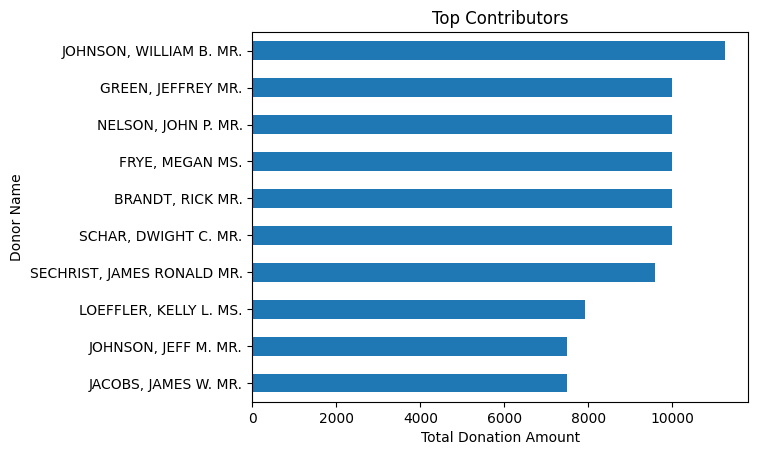

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import csv



# fixing row structure which was broken

clean_rows = []


with open('/content/fec_data(in).csv', 'r', errors='ignore') as f:
    reader = csv.reader(f)

    # rows = list(reader)
    # print("rows before cleaning:", len(rows))

    next(reader)
    for each_row_in_file in reader:
        raw = each_row_in_file[0]
        raw = raw.replace(';;;;', '')
        fixed_row = list(csv.reader([raw]))[0]

        if len(fixed_row) >= 16:
            clean_rows.append(fixed_row)
        # if len(fixed_row) >= 16:
        #     fixed_row = fixed_row[:16]
        #     clean_rows.append(fixed_row)



#creating df

columns = [
    'cmte_id','cand_id','cand_nm','contbr_nm','contbr_city',
    'contbr_st','contbr_zip','contbr_employer','contbr_occupation',
    'contb_receipt_amt($)','contb_receipt_dt','receipt_desc',
    'memo_cd','memo_text','form_tp','file_num'
]

df = pd.DataFrame(clean_rows, columns=columns)


print("Rows after fixing:", len(df))
print(df.head())

#data types cleaning

df['contb_receipt_amt($)'] = pd.to_numeric(df['contb_receipt_amt($)'], errors='coerce')
df['contb_receipt_dt'] = pd.to_datetime(df['contb_receipt_dt'], errors='coerce')

df['contbr_employer'] = df['contbr_employer'].fillna('NOT PROVIDED')
df['contbr_occupation'] = df['contbr_occupation'].fillna('NOT PROVIDED')


#valid data filtering

print("Valid amounts:", df['contb_receipt_amt($)'].notna().sum())

df = df[df['contb_receipt_amt($)'].notna()]

print("Rows after cleaning:", len(df))


# Analysis started

# Top donors
top_donors = df.groupby('contbr_nm')['contb_receipt_amt($)'].sum().sort_values(ascending=False).head(10)

print("\nTop Donors:\n", top_donors)

if top_donors.empty:
  print("nothing to print")
else:
    plt.figure()
    top_donors.sort_values().plot(kind='barh')

    plt.title('Top Contributors')
    plt.xlabel('Total Donation Amount')
    plt.ylabel('Donor Name')


# Occupation stats
occ_stats = df.groupby('contbr_occupation')['contb_receipt_amt($)'].agg(['count','mean','sum']).sort_values('sum', ascending=False)

print("\nOccupation Stats:\n", occ_stats.head(10))

# Employer stats
emp_stats = df.groupby('contbr_employer')['contb_receipt_amt($)'].agg(['count','sum']).sort_values('sum', ascending=False)

print("\nEmployer Stats:\n", emp_stats.head(10))

# State stats
state_stats = df.groupby('contbr_st')['contb_receipt_amt($)'].agg(['count','sum']).sort_values('sum', ascending=False)

print("\nState Stats:\n", state_stats.head(10))

# Top leader
leader_totals = df.groupby('cand_nm')['contb_receipt_amt($)'].sum().sort_values(ascending=False)

if not leader_totals.empty:
    print("\nTop Leader:", leader_totals.index[0])

# Sort by address
df_sorted = df.sort_values(by=['contbr_st','contbr_city'])

# State → Candidate
state_leader = df[['contbr_st','cand_nm']].drop_duplicates().sort_values('contbr_st')

print("\nState → Candidate:\n", state_leader.head(10))

# # creating to save version of ceaned file

# df.to_csv('/content/cleaned_fec_data.csv', index=False)

# print("\nCleaned file saved successfully!")




In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import csv


# # df = pd.read_csv('/content/fec_data(in).csv',
# #     engine='python',
# #     on_bad_lines='skip'
# # )

# # print(df.shape)
# # print(df.head())


# # with open('/content/fec_data(in).csv', 'r', errors='ignore') as f:
# #     for i in range(10):
# #         print(f.readline())

# with open('/content/fec_data(in).csv', 'r', errors='ignore') as f:
#     lines = f.readlines()

# print(len(lines))
# # print(lines[:3])
# for line in lines[:3]:
#   print(line)


# cleaned = []

# for line in lines:
#     line = line.replace(';;;;', ',')   # fix broken separators
#     line = line.replace('""""', '"')   # fix broken quotes
#     cleaned.append(line)


# rows = []

# for line in cleaned:
#     parts = line.split(',')

#     if len(parts) >= 16:
#         rows.append(parts[:16])

# df = pd.DataFrame(rows)

# print(df.shape)


# import pandas as pd

# df = pd.DataFrame(rows)

# print(df.shape)

# print(lengths)
# print(len(rows))

# print("cleaned lines:", len(cleaned))
# print("rows parsed:", len(rows))
# # print(rows[:2])
# for row in rows[:2]:
#   print(rows)


# len(cleaned)
# len(rows)


# print("Shape:", df.shape)
# print(df.head())
# print(df.info())

# print(df['contb_receipt_amt'].dtype)
# print(df['contb_receipt_amt'].isna().sum())


# top_donors = (
#     df.groupby('contbr_nm')['contb_receipt_amt']
#     .sum()
#     .sort_values(ascending=False)
#     .head(10)
# )

# print(top_donors)


1001732
cmte_id,cand_id,cand_nm,contbr_nm,contbr_city,contbr_st,contbr_zip,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,receipt_desc,memo_cd,memo_text,form_tp,file_num;;;;

"C00410118,""P20002978"",""Bachmann, Michelle"",""HARVEY, WILLIAM"",""MOBILE"",""AL"",""366010290"",""RETIRED"",""RETIRED"",250,20-JUN-11,"""","""","""",""SA17A"",736166";;;;

"C00410118,""P20002978"",""Bachmann, Michelle"",""HARVEY, WILLIAM"",""MOBILE"",""AL"",""366010290"",""RETIRED"",""RETIRED"",50,23-JUN-11,"""","""","""",""SA17A"",736166";;;;

(1001732, 16)
Buffered data was truncated after reaching the output size limit.